# Machine Learning aplicado a sistemas de recomendación cinematográfica

## Predicción de ratings y recomendación personalizada con MovieLens

Este notebook contiene el desarrollo técnico del sistema de recomendación cinematográfica construido a partir del dataset público **MovieLens**.

El objetivo es analizar las valoraciones de los usuarios sobre películas, preparar los datos, construir distintos modelos de recomendación y comparar su rendimiento mediante métricas de error predictivo y métricas de ranking.

Se trabajan cinco enfoques:

1. **Modelo base**: predice usando promedios generales, por usuario y por película.
2. **Filtrado colaborativo item-item con kNN**: estima recomendaciones a partir de películas similares según el comportamiento de los usuarios.
3. **Modelo basado en contenido**: recomienda películas similares usando los géneros como características principales.
4. **Factorización matricial**: aprende factores latentes de usuarios y películas para predecir ratings.
5. **Modelo híbrido**: combina filtrado colaborativo y contenido.


## 1. Preparación del entorno

En esta sección se importan las librerías necesarias para la carga de datos, análisis exploratorio, construcción de modelos, evaluación y visualización de resultados.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carga del dataset MovieLens

Se utiliza el conjunto de datos **MovieLens Latest Small**, que contiene aproximadamente 100.000 valoraciones de usuarios sobre películas.

Esta versión es adecuada para el desarrollo local del proyecto, ya que permite implementar, entrenar y comparar distintos modelos de recomendación sin requerir infraestructura de alto rendimiento.

Archivos principales:

- `ratings.csv`: contiene las valoraciones realizadas por los usuarios.
- `movies.csv`: contiene el catálogo de películas y sus géneros asociados.

In [2]:
from pathlib import Path

DATA_DIR = Path("data")

ratings_path = DATA_DIR / "ratings.csv"
movies_path = DATA_DIR / "movies.csv"

if not ratings_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {ratings_path}")

if not movies_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {movies_path}")

ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)

print("ratings:", ratings.shape)
print("movies:", movies.shape)

display(ratings.head())
display(movies.head())

ratings: (100836, 4)
movies: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 3. Revisión inicial de los datos

Antes de construir los modelos, se revisa la estructura de los archivos cargados para identificar las variables disponibles, comprobar dimensiones, detectar valores nulos y validar que la información pueda utilizarse correctamente en las siguientes fases del análisis.

In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
print("Información de ratings")
print(ratings.info())

print("\nValores nulos en ratings")
print(ratings.isna().sum())

print("\nValores nulos en movies")
print(movies.isna().sum())

Información de ratings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Valores nulos en ratings
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Valores nulos en movies
movieId    0
title      0
genres     0
dtype: int64


## 4. Limpieza y enriquecimiento básico

En esta sección se realizan transformaciones iniciales sobre los datos. Se convierte el campo `timestamp` a formato de fecha y se extrae el año incluido en el título de las películas cuando está disponible.

Estas variables permiten enriquecer el análisis exploratorio y facilitar una mejor comprensión del conjunto de datos antes de construir los modelos de recomendación.

In [6]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year_rating"] = ratings["datetime"].dt.year

movies["movie_year"] = movies["title"].str.extract(r"\((\d{4})\)").astype(float)
movies["clean_title"] = movies["title"].str.replace(r"\s*\(\d{4}\)", "", regex=True)
movies["genres_text"] = movies["genres"].str.replace("|", " ", regex=False).replace("(no genres listed)", "")

ratings_movies = ratings.merge(movies, on="movieId", how="left")
ratings_movies.head()

,userId,movieId,rating,timestamp,datetime,year_rating,title,genres,movie_year,clean_title,genres_text
0,1,1,4.0,964982703,2000-07-30 18:45:03,2000,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,Toy Story,Adventure Animation Children Comedy Fantasy
1,1,3,4.0,964981247,2000-07-30 18:20:47,2000,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,Comedy Romance
2,1,6,4.0,964982224,2000-07-30 18:37:04,2000,Heat (1995),Action|Crime|Thriller,1995.0,Heat,Action Crime Thriller
3,1,47,5.0,964983815,2000-07-30 19:03:35,2000,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1995.0,Seven (a.k.a. Se7en),Mystery Thriller
4,1,50,5.0,964982931,2000-07-30 18:48:51,2000,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1995.0,"Usual Suspects, The",Crime Mystery Thriller


## 5. Análisis exploratorio de datos (EDA)

El análisis exploratorio permite comprender la estructura del conjunto de datos antes de construir los modelos de recomendación. En esta fase se revisa el comportamiento de los usuarios, las películas y las valoraciones registradas.

En el contexto de los sistemas de recomendación, resulta especialmente importante analizar:

- cantidad de usuarios, películas y valoraciones;
- distribución de las calificaciones;
- actividad de los usuarios;
- popularidad de las películas;
- frecuencia de los géneros cinematográficos;
- dispersión de la matriz usuario-película;
- posibles sesgos asociados a la popularidad.

In [7]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)

print(f"Usuarios únicos: {n_users:,}")
print(f"Películas valoradas: {n_movies:,}")
print(f"Valoraciones totales: {n_ratings:,}")
print(f"Rating promedio: {ratings['rating'].mean():.3f}")
print(f"Rating mínimo: {ratings['rating'].min()}")
print(f"Rating máximo: {ratings['rating'].max()}")

Usuarios únicos: 610
Películas valoradas: 9,724
Valoraciones totales: 100,836
Rating promedio: 3.502
Rating mínimo: 0.5
Rating máximo: 5.0


### 5.1 Distribución de calificaciones

Se analiza la frecuencia de las calificaciones otorgadas por los usuarios. Esta revisión permite identificar si existe una concentración de valoraciones en determinados rangos, por ejemplo, una tendencia hacia puntuaciones medias o altas.

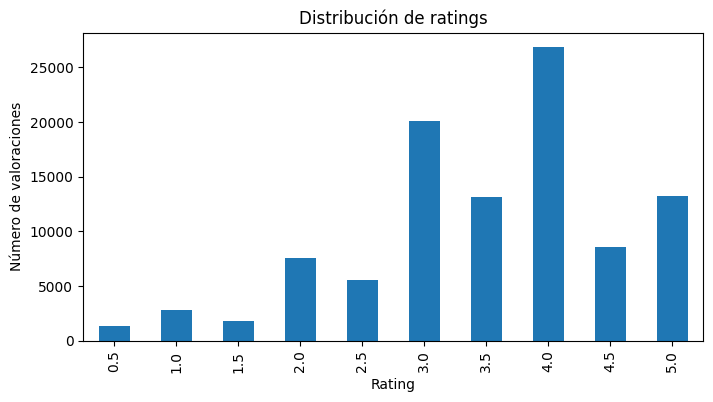

In [8]:
plt.figure(figsize=(8, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de ratings")
plt.xlabel("Rating")
plt.ylabel("Número de valoraciones")
plt.show()

**Interpretación:** en el conjunto de datos se observa una mayor concentración de calificaciones en valores medios y altos, especialmente entre 3 y 4 estrellas. Esto sugiere que los usuarios tienden a valorar principalmente películas que han decidido consumir y que, en general, reciben una valoración positiva o moderadamente positiva.

### 5.2 Actividad de usuarios y popularidad de películas

Se analiza la cantidad de valoraciones realizadas por cada usuario y el número de valoraciones recibidas por cada película. Esta revisión permite identificar diferencias en el nivel de actividad de los usuarios y posibles sesgos de popularidad entre los títulos del catálogo.

In [9]:
ratings_per_user = ratings.groupby("userId")["rating"].count()
ratings_per_movie = ratings.groupby("movieId")["rating"].count()

print("Valoraciones por usuario")
print(ratings_per_user.describe())

print("\nValoraciones por película")
print(ratings_per_movie.describe())

Valoraciones por usuario
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64

Valoraciones por película
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64


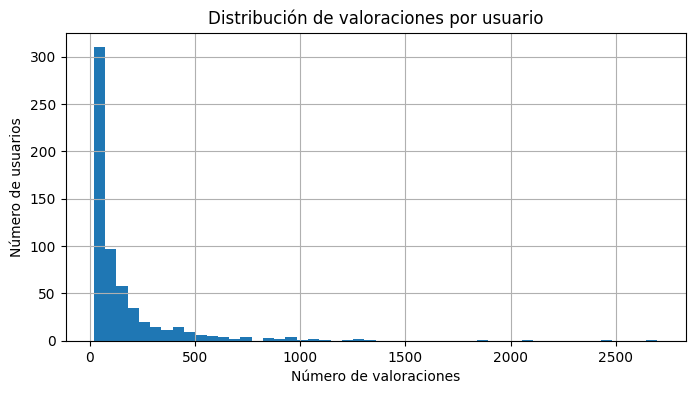

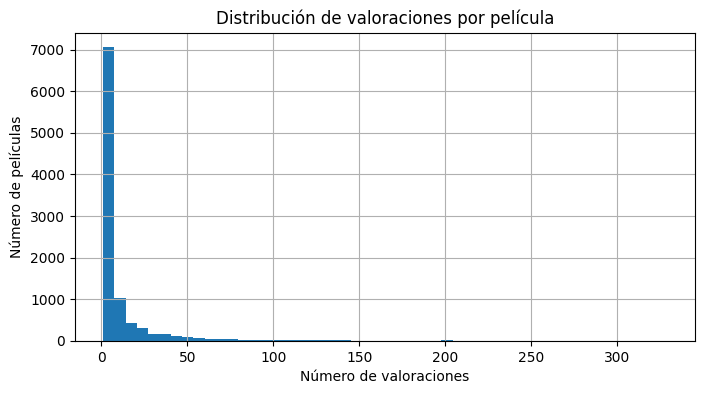

In [10]:
plt.figure(figsize=(8, 4))
ratings_per_user.hist(bins=50)
plt.title("Distribución de valoraciones por usuario")
plt.xlabel("Número de valoraciones")
plt.ylabel("Número de usuarios")
plt.show()

plt.figure(figsize=(8, 4))
ratings_per_movie.hist(bins=50)
plt.title("Distribución de valoraciones por película")
plt.xlabel("Número de valoraciones")
plt.ylabel("Número de películas")
plt.show()

### 5.3 Películas con mayor número de valoraciones

Se identifican las películas que concentran el mayor número de valoraciones dentro del conjunto de datos. Este análisis permite reconocer títulos con alta popularidad y mayor respaldo estadístico frente a películas con pocas interacciones.

In [11]:
movie_stats = ratings.groupby("movieId").agg(
    rating_count=("rating", "count"),
    rating_mean=("rating", "mean")
).reset_index().merge(movies, on="movieId", how="left")

movie_stats.sort_values("rating_count", ascending=False).head(10)[["title", "rating_count", "rating_mean", "genres"]]

,title,rating_count,rating_mean,genres
314,Forrest Gump (1994),329,4.164134,Comedy|Drama|Romance|War
277,"Shawshank Redemption, The (1994)",317,4.429022,Crime|Drama
257,Pulp Fiction (1994),307,4.197068,Comedy|Crime|Drama|Thriller
510,"Silence of the Lambs, The (1991)",279,4.161290,Crime|Horror|Thriller
1938,"Matrix, The (1999)",278,4.192446,Action|Sci-Fi|Thriller
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076,Action|Adventure|Sci-Fi
418,Jurassic Park (1993),238,3.750000,Action|Adventure|Sci-Fi|Thriller
97,Braveheart (1995),237,4.031646,Action|Drama|War
507,Terminator 2: Judgment Day (1991),224,3.970982,Action|Sci-Fi
461,Schindler's List (1993),220,4.225000,Drama|War


In [12]:
min_votes = 50
movie_stats[movie_stats["rating_count"] >= min_votes] \
    .sort_values("rating_mean", ascending=False) \
    .head(10)[["title", "rating_count", "rating_mean", "genres"]]

,title,rating_count,rating_mean,genres
277,"Shawshank Redemption, The (1994)",317,4.429022,Crime|Drama
659,"Godfather, The (1972)",192,4.289062,Crime|Drama
2224,Fight Club (1999),218,4.272936,Action|Crime|Drama|Thriller
974,Cool Hand Luke (1967),57,4.271930,Drama
602,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,Comedy|War
686,Rear Window (1954),84,4.261905,Mystery|Thriller
921,"Godfather: Part II, The (1974)",129,4.259690,Crime|Drama
6298,"Departed, The (2006)",107,4.252336,Crime|Drama|Thriller
913,Goodfellas (1990),126,4.250000,Crime|Drama
694,Casablanca (1942),100,4.240000,Drama|Romance


### 5.4 Promedio bayesiano

El promedio aritmético simple puede favorecer películas con pocas valoraciones y calificaciones altas, generando una interpretación poco robusta de su popularidad o calidad percibida. Para reducir este sesgo, se calcula un promedio bayesiano que combina la calificación media de cada película con el número de valoraciones recibidas y el promedio general del sistema.

In [13]:
C = ratings["rating"].mean()
m = movie_stats["rating_count"].quantile(0.80)

movie_stats["bayesian_score"] = (
    (movie_stats["rating_count"] / (movie_stats["rating_count"] + m)) * movie_stats["rating_mean"] +
    (m / (movie_stats["rating_count"] + m)) * C
)

movie_stats.sort_values("bayesian_score", ascending=False).head(10)[["title", "rating_count", "rating_mean", "bayesian_score", "genres"]]

,title,rating_count,rating_mean,bayesian_score,genres
277,"Shawshank Redemption, The (1994)",317,4.429022,4.395194,Crime|Drama
659,"Godfather, The (1972)",192,4.289062,4.242739,Crime|Drama
2224,Fight Club (1999),218,4.272936,4.232690,Action|Crime|Drama|Thriller
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076,4.197790,Action|Adventure|Sci-Fi
46,"Usual Suspects, The (1995)",204,4.237745,4.196846,Crime|Mystery|Thriller
921,"Godfather: Part II, The (1974)",129,4.259690,4.195168,Crime|Drama
461,Schindler's List (1993),220,4.225000,4.187581,Drama|War
913,Goodfellas (1990),126,4.250000,4.184918,Crime|Drama
602,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,4.183658,Comedy|War
6693,"Dark Knight, The (2008)",149,4.238255,4.183346,Action|Crime|Drama|IMAX


### 5.5 Análisis por géneros

Se revisa la distribución de géneros cinematográficos presentes en el catálogo. Este análisis permite conocer qué tipos de películas tienen mayor presencia en el conjunto de datos y sirve como base para el modelo basado en contenido, que utiliza los géneros como variable descriptiva principal.

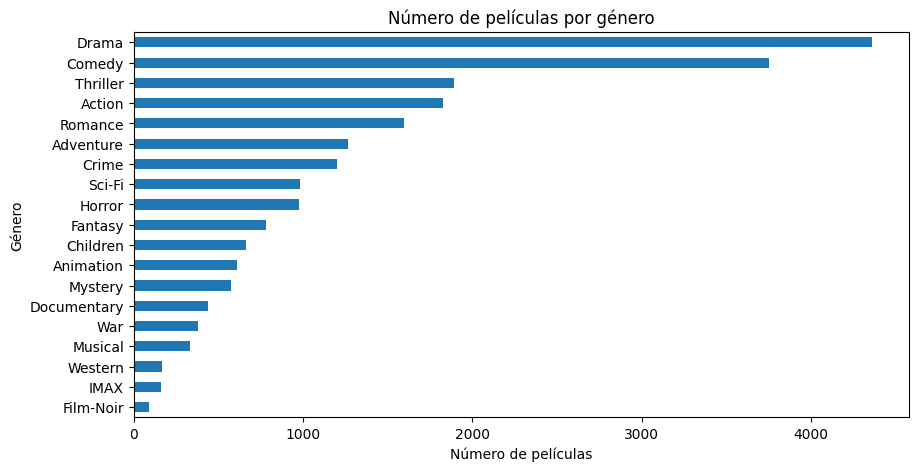

In [14]:
genres_exploded = movies.assign(genre=movies["genres"].str.split("|")).explode("genre")
genres_exploded = genres_exploded[genres_exploded["genre"] != "(no genres listed)"]

genre_counts = genres_exploded["genre"].value_counts()

plt.figure(figsize=(10, 5))
genre_counts.sort_values().plot(kind="barh")
plt.title("Número de películas por género")
plt.xlabel("Número de películas")
plt.ylabel("Género")
plt.show()

In [15]:
ratings_genres = ratings.merge(genres_exploded[["movieId", "genre"]], on="movieId", how="left")
genre_rating_stats = ratings_genres.groupby("genre").agg(
    rating_count=("rating", "count"),
    rating_mean=("rating", "mean")
).sort_values("rating_mean", ascending=False)

genre_rating_stats

,rating_count,rating_mean
genre,,
Film-Noir,870,3.920115
War,4859,3.808294
Documentary,1219,3.797785
Crime,16681,3.658294
Drama,41928,3.656184
Mystery,7674,3.632460
Animation,6988,3.629937
IMAX,4145,3.618335
Western,1930,3.583938


### 5.6 Dispersión de la matriz usuario-película

Se calcula la densidad y dispersión de la matriz usuario-película para cuantificar el nivel de información disponible. En este tipo de problemas, la mayoría de combinaciones entre usuarios y películas no cuenta con una valoración explícita, lo que dificulta la predicción directa de calificaciones.

Este análisis justifica el uso de modelos capaces de trabajar con matrices dispersas, como el filtrado colaborativo y la factorización matricial.

In [16]:
possible_ratings = n_users * n_movies
sparsity = 1 - (n_ratings / possible_ratings)

print(f"Tamaño teórico de la matriz usuario-película: {possible_ratings:,}")
print(f"Ratings observados: {n_ratings:,}")
print(f"Sparsity: {sparsity:.2%}")

Tamaño teórico de la matriz usuario-película: 5,931,640
Ratings observados: 100,836
Sparsity: 98.30%


## 6. Preparación para entrenamiento y evaluación

Se divide el dataset en entrenamiento y prueba.

- **Train**: datos usados para construir los modelos.
- **Test**: datos no vistos durante el entrenamiento, usados para evaluar.

Esta separación es clave para medir si el modelo realmente generaliza.



In [17]:
train_df, test_df = train_test_split(
    ratings[["userId", "movieId", "rating"]],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=ratings["userId"] if ratings.groupby("userId").size().min() > 1 else None
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Usuarios en train:", train_df["userId"].nunique())
print("Películas en train:", train_df["movieId"].nunique())

test_sample = test_df.sample(
    n=min(5000, len(test_df)),
    random_state=RANDOM_STATE
)

print("Test sample:", test_sample.shape)

Train: (80668, 3)
Test: (20168, 3)
Usuarios en train: 610
Películas en train: 8977
Test sample: (5000, 3)


### 6.1 Funciones auxiliares de evaluación

Se definen funciones comunes para calcular RMSE y MAE.

- **RMSE** penaliza más los errores grandes.
- **MAE** mide el error promedio absoluto.

Ambas métricas son útiles cuando se busca predecir ratings.

In [18]:
def clip_rating(x, min_rating=0.5, max_rating=5.0):
    return np.clip(x, min_rating, max_rating)


def regression_metrics(y_true, y_pred):
    y_pred = clip_rating(np.array(y_pred))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae}

results = []

## 7. Modelo base: promedio global, usuario y película

Antes de usar modelos más complejos, se construye una línea base.

La idea es simple:

- si conocemos el promedio de una película, usamos ese promedio;
- si no, usamos el promedio del usuario;
- si tampoco está disponible, usamos el promedio global.

Este modelo permite saber si los modelos avanzados realmente aportan mejora.

In [19]:
global_mean = train_df["rating"].mean()
user_mean = train_df.groupby("userId")["rating"].mean()
movie_mean = train_df.groupby("movieId")["rating"].mean()


def predict_baseline(row):
    movie_id = row["movieId"]
    user_id = row["userId"]
    if movie_id in movie_mean.index:
        return movie_mean.loc[movie_id]
    elif user_id in user_mean.index:
        return user_mean.loc[user_id]
    else:
        return global_mean


baseline_pred = test_sample.apply(predict_baseline, axis=1)
baseline_metrics = regression_metrics(test_sample["rating"], baseline_pred)

results.append({"Modelo": "Base promedio", "Tipo": "Baseline", **baseline_metrics})

baseline_metrics

{'RMSE': np.float64(0.9773915684763717), 'MAE': 0.7547018307263372}

## 8. Modelo colaborativo item-item con kNN

El filtrado colaborativo usa el comportamiento de los usuarios.

En este caso se usa un enfoque **item-item**:

- se representa cada película como un vector de ratings de usuarios;
- se calcula la similitud entre películas;
- para predecir el rating de una película, se buscan películas similares que el usuario ya valoró.

Este enfoque funciona bien cuando existen suficientes valoraciones históricas.

In [20]:
# Índices internos para construir la matriz dispersa
user_ids = sorted(train_df["userId"].unique())
movie_ids = sorted(train_df["movieId"].unique())

user_to_idx = {u: i for i, u in enumerate(user_ids)}
movie_to_idx = {m: i for i, m in enumerate(movie_ids)}
idx_to_movie = {i: m for m, i in movie_to_idx.items()}

row = train_df["userId"].map(user_to_idx)
col = train_df["movieId"].map(movie_to_idx)
data = train_df["rating"].values

user_movie_matrix = csr_matrix((data, (row, col)), shape=(len(user_ids), len(movie_ids)))
movie_user_matrix = user_movie_matrix.T

print("Matriz usuario-película:", user_movie_matrix.shape)

Matriz usuario-película: (610, 8977)


In [21]:
# Similitud item-item basada en coseno
item_similarity = cosine_similarity(movie_user_matrix, dense_output=False)
print("Matriz de similitud item-item:", item_similarity.shape)

Matriz de similitud item-item: (8977, 8977)


In [22]:
def predict_item_knn(user_id, movie_id, k=30):
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return predict_baseline({"userId": user_id, "movieId": movie_id})
    
    u_idx = user_to_idx[user_id]
    m_idx = movie_to_idx[movie_id]
    
    user_ratings = user_movie_matrix[u_idx].toarray().ravel()
    rated_items = np.where(user_ratings > 0)[0]
    
    if len(rated_items) == 0:
        return global_mean
    
    sims = item_similarity[m_idx, rated_items].toarray().ravel()
    ratings_user = user_ratings[rated_items]
    
    positive = sims > 0
    sims = sims[positive]
    ratings_user = ratings_user[positive]
    
    if len(sims) == 0:
        return predict_baseline({"userId": user_id, "movieId": movie_id})
    
    top_idx = np.argsort(sims)[-k:]
    sims_top = sims[top_idx]
    ratings_top = ratings_user[top_idx]
    
    return np.dot(sims_top, ratings_top) / sims_top.sum()

knn_pred = [predict_item_knn(row.userId, row.movieId, k=30) for row in test_sample.itertuples(index=False)]
knn_metrics = regression_metrics(test_sample["rating"], knn_pred)
results.append({"Modelo": "kNN item-item", "Tipo": "Colaborativo", **knn_metrics})
knn_metrics

{'RMSE': np.float64(0.8744114953525591), 'MAE': 0.6690103964311995}

## 9. Modelo basado en contenido por géneros

El modelo basado en contenido no depende tanto de otros usuarios. Usa características de las películas.

En este caso se usan los géneros como texto. Por ejemplo:

- `Action Adventure Sci-Fi`
- `Comedy Romance`
- `Drama Thriller`

Luego se calcula similitud entre películas con TF-IDF y coseno.

Este modelo ayuda especialmente cuando se desea recomendar películas parecidas a las que el usuario ya valoró positivamente.

In [23]:
# Crear el vectorizador TF-IDF
# TF-IDF convierte palabras en pesos numéricos
tfidf = TfidfVectorizer(token_pattern=r"[^\s]+")

# Construcción de la matriz TF-IDF, matriz películas × géneros
content_matrix = tfidf.fit_transform(movies["genres_text"].fillna(""))

# Calcular similitud coseno
content_similarity = cosine_similarity(content_matrix, dense_output=False)

# Crear diccionario movieId → índice
movieid_to_content_idx = {m: i for i, m in enumerate(movies["movieId"])}

# Diccionario inverso
content_idx_to_movieid = {i: m for m, i in movieid_to_content_idx.items()}

print("Matriz de contenido:", content_matrix.shape)
print("Variables de contenido:", tfidf.get_feature_names_out())

Matriz de contenido: (9742, 19)
Variables de contenido: ['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'film-noir' 'horror' 'imax' 'musical'
 'mystery' 'romance' 'sci-fi' 'thriller' 'war' 'western']


In [24]:
def predict_content(user_id, movie_id, k=30):

    # Si la película no tiene representación TF-IDF
    # no se puede calcular similitud, usa el modelo baseline como respaldo
    if movie_id not in movieid_to_content_idx:
        return predict_baseline({"userId": user_id, "movieId": movie_id})
    
    # Busca todas las películas calificadas por ese usuario.
    user_history = train_df[train_df["userId"] == user_id]

    # Si el usuario no tiene historial, devuelve promedio general 
    if user_history.empty:
        return global_mean
    
    # Obtiene índice de la película objetivo
    target_idx = movieid_to_content_idx[movie_id]

    # Obtiene películas calificadas y ratings
    rated_movie_ids = user_history["movieId"].values
    rated_ratings = user_history["rating"].values
    
    # Filtra películas válidas
    valid = [m in movieid_to_content_idx for m in rated_movie_ids]
    if not any(valid):
        return predict_baseline({"userId": user_id, "movieId": movie_id})
    
    rated_movie_ids = rated_movie_ids[valid]
    rated_ratings = rated_ratings[valid]

    # Convierte movieId a índices TF-IDF
    rated_idx = [movieid_to_content_idx[m] for m in rated_movie_ids]
    
    # Calcula similitud de contenido
    sims = content_similarity[target_idx, rated_idx].toarray().ravel()

    # Conserva solo similitudes positivas
    positive = sims > 0
    sims = sims[positive]
    rated_ratings = rated_ratings[positive]
    
    # Si no hay similitudes
    if len(sims) == 0:
        return predict_baseline({"userId": user_id, "movieId": movie_id})
    
    # Selecciona las k películas más similares
    top_idx = np.argsort(sims)[-k:]
    sims_top = sims[top_idx]
    ratings_top = rated_ratings[top_idx]
    
    #Predicción final
    return np.dot(sims_top, ratings_top) / sims_top.sum()

content_pred = [predict_content(row.userId, row.movieId, k=30) for row in test_sample.itertuples(index=False)]
content_metrics = regression_metrics(test_sample["rating"], content_pred)
results.append({"Modelo": "Contenido por géneros", "Tipo": "Basado en contenido", **content_metrics})
content_metrics

{'RMSE': np.float64(0.9258735448968323), 'MAE': 0.7158646858703703}

## 10. Factorización matricial con SGD

La factorización matricial busca representar usuarios y películas en un espacio de factores latentes.

La idea es que el rating se puede aproximar así:

`rating ≈ promedio global + sesgo del usuario + sesgo de la película + interacción usuario-película`

Los factores latentes no son variables observadas directamente. El modelo las aprende durante el entrenamiento. Pueden capturar patrones como afinidad por ciertos tipos de cine, popularidad, estilo, tono o combinaciones de géneros.

Este enfoque es muy usado en sistemas recomendadores porque permite predecir ratings no observados.

In [25]:
class MatrixFactorizationSGD:
    def __init__(self, n_factors=30, lr=0.01, reg=0.05, n_epochs=15, random_state=42):
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.random_state = random_state
    
    def fit(self, df):
        rng = np.random.default_rng(self.random_state)
        self.global_mean_ = df["rating"].mean()
        
        # Usuarios y películas únicas
        self.user_ids_ = sorted(df["userId"].unique())
        self.movie_ids_ = sorted(df["movieId"].unique())

        # Diccionarios de conversión
        self.user_to_idx_ = {u: i for i, u in enumerate(self.user_ids_)}
        self.movie_to_idx_ = {m: i for i, m in enumerate(self.movie_ids_)}
        
        # Número de usuarios y películas
        n_users = len(self.user_ids_)
        n_movies = len(self.movie_ids_)
        
        # Matrices latentes P y Q
        self.P_ = rng.normal(0, 0.1, size=(n_users, self.n_factors))
        self.Q_ = rng.normal(0, 0.1, size=(n_movies, self.n_factors))

        # Sesgos de usuarios y películas
        self.bu_ = np.zeros(n_users)
        self.bi_ = np.zeros(n_movies)
        
        # Mezcla los datos
        train = df.sample(frac=1, random_state=self.random_state).reset_index(drop=True)
        
        # Bucle de entrenamiento por épocas
        for epoch in range(self.n_epochs):
            squared_error = 0
            # Recorre cada rating
            for row in train.itertuples(index=False):
                # Convierte IDs a índices
                u = self.user_to_idx_[row.userId]
                i = self.movie_to_idx_[row.movieId]
                r = row.rating
                
                # Calcula predicción
                # Combina media global + sesgo del usuario + sesgo de la película+ relación latente usuario-película

                # predicción = promedio general + ajuste usuario + ajuste película + compatibilidad
                pred = self.global_mean_ + self.bu_[u] + self.bi_[i] + np.dot(self.P_[u], self.Q_[i])

                # Calcula error: Compara rating real - rating predicho
                err = r - pred
                # Acumula error cuadrático
                squared_error += err ** 2
                
                # Copia factores antiguos
                p_old = self.P_[u].copy()
                q_old = self.Q_[i].copy()
                
                # Actualiza sesgo del usuario
                self.bu_[u] += self.lr * (err - self.reg * self.bu_[u])
                # Actualiza sesgo de la película
                self.bi_[i] += self.lr * (err - self.reg * self.bi_[i])
                # Actualiza factores del usuarioo
                self.P_[u] += self.lr * (err * q_old - self.reg * p_old)
                # Actualiza factores de la película
                self.Q_[i] += self.lr * (err * p_old - self.reg * q_old)

            # Calcula RMSE de entrenamiento
            rmse_train = np.sqrt(squared_error / len(train))
            print(f"Época {epoch + 1:02d}/{self.n_epochs} - RMSE entrenamiento: {rmse_train:.4f}")
        
        return self
    
    # Método predict_one, Predice el rating para un usuario y una película.
    def predict_one(self, user_id, movie_id):

        if user_id not in self.user_to_idx_ or movie_id not in self.movie_to_idx_:
            return self.global_mean_
        
        u = self.user_to_idx_[user_id]
        i = self.movie_to_idx_[movie_id]

        # Calcula predicción final
        pred = self.global_mean_ + self.bu_[u] + self.bi_[i] + np.dot(self.P_[u], self.Q_[i])
        return clip_rating(pred)
    
    # Método predict, Predice muchos registros a la vez.
    def predict(self, df):
        return np.array([self.predict_one(row.userId, row.movieId) for row in df.itertuples(index=False)])

In [26]:
mf_model = MatrixFactorizationSGD(n_factors=30, lr=0.01, reg=0.05, n_epochs=15, random_state=RANDOM_STATE)
mf_model.fit(train_df)

mf_pred = mf_model.predict(test_sample)
mf_metrics = regression_metrics(test_sample["rating"], mf_pred)
results.append({"Modelo": "Factorización matricial", "Tipo": "Latente / colaborativo", **mf_metrics})
mf_metrics

Época 01/15 - RMSE entrenamiento: 0.9452
Época 02/15 - RMSE entrenamiento: 0.8904
Época 03/15 - RMSE entrenamiento: 0.8700
Época 04/15 - RMSE entrenamiento: 0.8565
Época 05/15 - RMSE entrenamiento: 0.8462
Época 06/15 - RMSE entrenamiento: 0.8374
Época 07/15 - RMSE entrenamiento: 0.8295
Época 08/15 - RMSE entrenamiento: 0.8220
Época 09/15 - RMSE entrenamiento: 0.8145
Época 10/15 - RMSE entrenamiento: 0.8068
Época 11/15 - RMSE entrenamiento: 0.7987
Época 12/15 - RMSE entrenamiento: 0.7900
Época 13/15 - RMSE entrenamiento: 0.7807
Época 14/15 - RMSE entrenamiento: 0.7707
Época 15/15 - RMSE entrenamiento: 0.7600


{'RMSE': np.float64(0.8874640285688997), 'MAE': 0.6824461706052025}

## 11. Modelo híbrido

El modelo híbrido combina dos enfoques:

- predicción colaborativa kNN;
- predicción basada en contenido.

La razón es que cada modelo tiene fortalezas distintas:

- el colaborativo aprende patrones de usuarios;
- el contenido ayuda cuando las películas comparten características similares;
- juntos pueden compensar algunas limitaciones.

Aquí se usa una combinación ponderada simple.

In [27]:
def predict_hybrid(user_id, movie_id, alpha=0.7):
    pred_cf = predict_item_knn(user_id, movie_id, k=30)
    pred_content = predict_content(user_id, movie_id, k=30)
    return alpha * pred_cf + (1 - alpha) * pred_content

hybrid_pred = [predict_hybrid(row.userId, row.movieId, alpha=0.7) for row in test_sample.itertuples(index=False)]
hybrid_metrics = regression_metrics(test_sample["rating"], hybrid_pred)
results.append({"Modelo": "Híbrido kNN + contenido", "Tipo": "Híbrido", **hybrid_metrics})
hybrid_metrics

{'RMSE': np.float64(0.8730903455557748), 'MAE': 0.6704350201497838}

## 12. Comparación de modelos para predicción de ratings

Se comparan los modelos con RMSE y MAE.

Un valor menor indica mejor capacidad de predicción.

In [28]:
results_df = pd.DataFrame(results).drop_duplicates(subset=["Modelo"], keep="last")
results_df = results_df.sort_values("RMSE")
results_df

,Modelo,Tipo,RMSE,MAE
4,Híbrido kNN + contenido,Híbrido,0.873090,0.670435
1,kNN item-item,Colaborativo,0.874411,0.669010
3,Factorización matricial,Latente / colaborativo,0.887464,0.682446
2,Contenido por géneros,Basado en contenido,0.925874,0.715865
0,Base promedio,Baseline,0.977392,0.754702


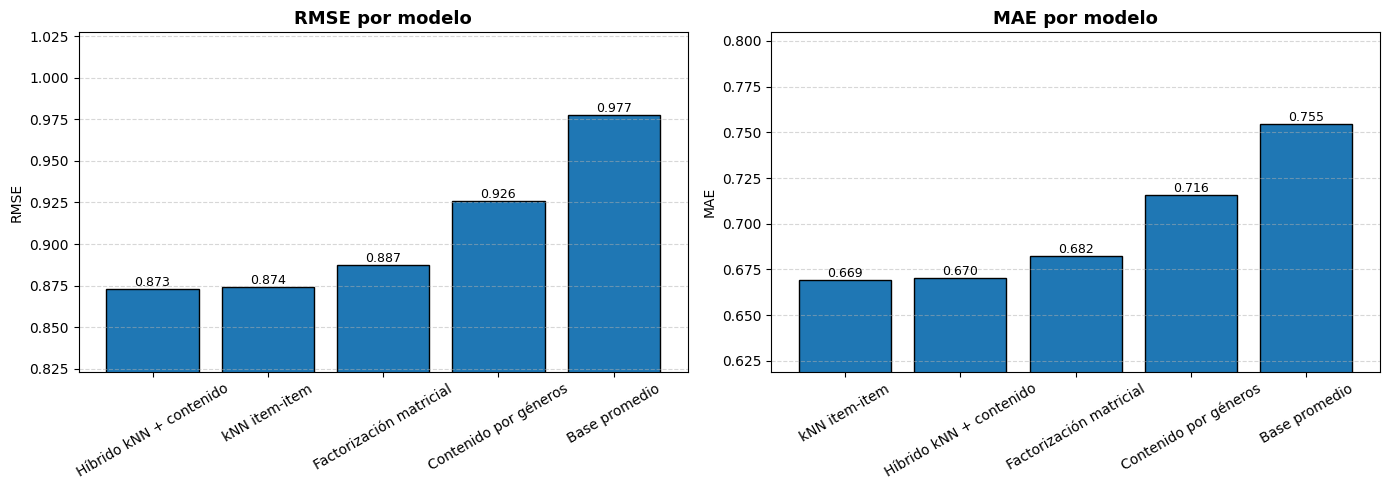

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- RMSE ----------------
results_sorted_rmse = results_df.sort_values("RMSE")

bars1 = axes[0].bar(
    results_sorted_rmse["Modelo"],
    results_sorted_rmse["RMSE"],
    edgecolor="black"
)

axes[0].set_title("RMSE por modelo", fontsize=13, fontweight="bold")
axes[0].set_ylabel("RMSE")

axes[0].set_ylim(
    results_sorted_rmse["RMSE"].min() - 0.05,
    results_sorted_rmse["RMSE"].max() + 0.05
)

axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=30)

# Valores sobre barras
for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# ---------------- MAE ----------------
results_sorted_mae = results_df.sort_values("MAE")

bars2 = axes[1].bar(
    results_sorted_mae["Modelo"],
    results_sorted_mae["MAE"],
    edgecolor="black"
)

axes[1].set_title("MAE por modelo", fontsize=13, fontweight="bold")
axes[1].set_ylabel("MAE")

axes[1].set_ylim(
    results_sorted_mae["MAE"].min() - 0.05,
    results_sorted_mae["MAE"].max() + 0.05
)

axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=30)

# Valores sobre barras
for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Criterios generales de interpretación:**

- El modelo base sirve como referencia mínima.
- El modelo kNN suele mejorar cuando existen suficientes usuarios con gustos similares.
- El modelo basado en contenido puede ser más limitado porque en este notebook usa solo géneros.
- La factorización matricial suele funcionar bien para predicción de ratings porque aprende patrones latentes.
- El híbrido puede mejorar la estabilidad, aunque su rendimiento depende del peso asignado a cada componente.

El mejor modelo no debe elegirse solo por una métrica. También debe considerarse interpretabilidad, facilidad de implementación, escalabilidad y manejo de usuarios o películas nuevas.

## 13. Generación de recomendaciones personalizadas

Ahora se construyen funciones para recomendar películas a un usuario específico.

La recomendación excluye películas que el usuario ya valoró.

In [30]:
def get_user_seen_movies(user_id):
    return set(ratings[ratings["userId"] == user_id]["movieId"])


def recommend_with_mf(user_id, top_n=10, min_votes=20):
    seen = get_user_seen_movies(user_id)
    candidate_movies = movie_stats[movie_stats["rating_count"] >= min_votes]["movieId"].tolist()
    candidate_movies = [m for m in candidate_movies if m not in seen and m in mf_model.movie_to_idx_]
    
    preds = [(m, mf_model.predict_one(user_id, m)) for m in candidate_movies]
    recs = pd.DataFrame(preds, columns=["movieId", "predicted_rating"])
    recs = recs.merge(movies, on="movieId", how="left")
    return recs.sort_values("predicted_rating", ascending=False).head(top_n)

sample_user = int(ratings["userId"].sample(1, random_state=RANDOM_STATE).iloc[0])
print("Usuario de ejemplo:", sample_user)
recommend_with_mf(sample_user, top_n=10)

Usuario de ejemplo: 432


,movieId,predicted_rating,title,genres,movie_year,clean_title,genres_text
197,899,4.581259,Singin' in the Rain (1952),Comedy|Musical|Romance,1952.0,Singin' in the Rain,Comedy Musical Romance
270,1204,4.544759,Lawrence of Arabia (1962),Adventure|Drama|War,1962.0,Lawrence of Arabia,Adventure Drama War
178,750,4.470953,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,1964.0,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy War
633,3275,4.413051,"Boondock Saints, The (2000)",Action|Crime|Drama|Thriller,2000.0,"Boondock Saints, The",Action Crime Drama Thriller
971,56782,4.397636,There Will Be Blood (2007),Drama|Western,2007.0,There Will Be Blood,Drama Western
279,1223,4.370797,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi,1989.0,"Grand Day Out with Wallace and Gromit, A",Adventure Animation Children Comedy Sci-Fi
66,246,4.370466,Hoop Dreams (1994),Documentary,1994.0,Hoop Dreams,Documentary
251,1104,4.345233,"Streetcar Named Desire, A (1951)",Drama,1951.0,"Streetcar Named Desire, A",Drama
303,1267,4.339882,"Manchurian Candidate, The (1962)",Crime|Thriller|War,1962.0,"Manchurian Candidate, The",Crime Thriller War
214,930,4.332254,Notorious (1946),Film-Noir|Romance|Thriller,1946.0,Notorious,Film-Noir Romance Thriller


### 13.1 Perfil simple del usuario recomendado

Para interpretar las recomendaciones, se revisan los géneros mejor valorados por el usuario.

In [31]:
def user_genre_profile(user_id):
    user_data = ratings_movies[ratings_movies["userId"] == user_id]
    user_genres = user_data.assign(genre=user_data["genres"].str.split("|")).explode("genre")
    profile = user_genres.groupby("genre").agg(
        rating_count=("rating", "count"),
        rating_mean=("rating", "mean")
    ).sort_values(["rating_mean", "rating_count"], ascending=False)
    return profile

user_genre_profile(sample_user).head(10)

,rating_count,rating_mean
genre,,
Musical,4,4.500000
Western,1,4.500000
IMAX,17,3.970588
Horror,21,3.928571
War,17,3.852941
Drama,146,3.818493
Romance,59,3.788136
Mystery,36,3.736111
Animation,15,3.733333


## 14. Evaluación de ranking: Precision@K y Recall@K

RMSE y MAE evalúan predicción de ratings, pero en sistemas recomendadores también importa si el modelo recomienda películas relevantes en los primeros lugares.

Se consideran relevantes las películas del conjunto de prueba con rating mayor o igual a 4.

- **Precision@K**: de las K películas recomendadas, cuántas fueron relevantes.
- **Recall@K**: de las películas relevantes del usuario, cuántas logró recuperar el modelo.

Esta evaluación se hace sobre usuarios con películas relevantes en test.

In [32]:
def construir_candidatos_ranking(users_eval, k=10, candidate_sample_size=200, random_state=42):
    """
    Construye una lista fija de candidatos por usuario para evaluar todos los modelos
    bajo las mismas condiciones.

    Esto evita que cada modelo sea evaluado con una muestra aleatoria diferente.
    """
    rng = np.random.default_rng(random_state)
    all_movie_ids = sorted(ratings["movieId"].unique())
    candidatos_por_usuario = {}

    for user_id in users_eval:
        # Películas relevantes del usuario en test
        relevant = set(
            test_df[
                (test_df["userId"] == user_id) &
                (test_df["rating"] >= 4.0)
            ]["movieId"]
        )

        if len(relevant) == 0:
            continue

        # Películas vistas en train, que no deben recomendarse
        seen_train = set(train_df[train_df["userId"] == user_id]["movieId"])

        # Candidatas: películas no vistas en train
        candidates = sorted(set(all_movie_ids) - seen_train)

        # Candidatas no relevantes para completar la muestra
        random_candidates = sorted(set(candidates) - relevant)

        # Muestreo fijo y reproducible
        if len(random_candidates) > candidate_sample_size:
            random_candidates = rng.choice(
                random_candidates,
                size=candidate_sample_size,
                replace=False
            ).tolist()

        # Se fuerza que las relevantes estén siempre dentro de la evaluación
        candidates_eval = sorted(set(relevant) | set(random_candidates))

        candidatos_por_usuario[user_id] = {
            "relevant": relevant,
            "candidates_eval": candidates_eval
        }

    return candidatos_por_usuario


def precision_recall_at_k(model_predict_func, candidatos_por_usuario, k=10):
    precisions = []
    recalls = []

    for user_id, data in candidatos_por_usuario.items():
        relevant = data["relevant"]
        candidates_eval = data["candidates_eval"]

        scores = [
            (m, model_predict_func(user_id, m))
            for m in candidates_eval
        ]

        top_k = [
            m for m, s in sorted(scores, key=lambda x: x[1], reverse=True)[:k]
        ]

        hits = len(set(top_k) & relevant)

        precisions.append(hits / k)
        recalls.append(hits / len(relevant))

    return {
        "Precision@K": np.mean(precisions) if precisions else 0,
        "Recall@K": np.mean(recalls) if recalls else 0,
        "Usuarios evaluados": len(precisions)
    }


# Selección fija de usuarios con al menos una película relevante en test
users_with_relevant = (
    test_df[test_df["rating"] >= 4.0]["userId"]
    .drop_duplicates()
    .sample(
        n=min(100, test_df[test_df["rating"] >= 4.0]["userId"].nunique()),
        random_state=RANDOM_STATE
    )
    .tolist()
)

# Construcción fija de candidatos para todos los modelos
candidatos_ranking = construir_candidatos_ranking(
    users_eval=users_with_relevant,
    k=10,
    candidate_sample_size=200,
    random_state=RANDOM_STATE
)

ranking_results = []

ranking_results.append({
    "Modelo": "Factorización matricial",
    **precision_recall_at_k(
        lambda u, m: mf_model.predict_one(u, m),
        candidatos_ranking,
        k=10
    )
})

ranking_results.append({
    "Modelo": "kNN item-item",
    **precision_recall_at_k(
        lambda u, m: predict_item_knn(u, m),
        candidatos_ranking,
        k=10
    )
})

ranking_results.append({
    "Modelo": "Contenido por géneros",
    **precision_recall_at_k(
        lambda u, m: predict_content(u, m),
        candidatos_ranking,
        k=10
    )
})

ranking_results.append({
    "Modelo": "Híbrido kNN + contenido",
    **precision_recall_at_k(
        lambda u, m: predict_hybrid(u, m),
        candidatos_ranking,
        k=10
    )
})

ranking_df = pd.DataFrame(ranking_results)

ranking_df_vis = ranking_df.sort_values("Precision@K", ascending=False).reset_index(drop=True)

ranking_df_vis["Precision@K"] = ranking_df_vis["Precision@K"].round(4)
ranking_df_vis["Recall@K"] = ranking_df_vis["Recall@K"].round(4)

# Identificar mejor modelo
max_precision = ranking_df_vis["Precision@K"].max()

def highlight_best(row):
    return [
        "font-weight: bold; background-color: #d9ead3" if row["Precision@K"] == max_precision else ""
        for _ in row
    ]

ranking_df_vis.style \
    .apply(highlight_best, axis=1) \
    .format({
        "Precision@K": "{:.4f}",
        "Recall@K": "{:.4f}",
        "Usuarios evaluados": "{:.0f}"
    }) \
    .set_caption("Comparación de modelos mediante métricas de ranking Precision@10 y Recall@10.") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("margin-bottom", "8px"),
                ("color", "white")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("border", "1px solid #cccccc"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("background-color", "white"),
                ("color", "black"),
                ("border", "1px solid #cccccc"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td.col0",
            "props": [
                ("text-align", "left")
            ]
        }
    ]) \
    .hide(axis="index")

Modelo,Precision@K,Recall@K,Usuarios evaluados
Factorización matricial,0.2850,0.2874,100
Híbrido kNN + contenido,0.1400,0.0509,100
kNN item-item,0.1350,0.0448,100
Contenido por géneros,0.0870,0.0555,100


**Nota metodológica:** esta evaluación de ranking utiliza una muestra controlada de candidatos para mantener un tiempo de ejecución razonable en el notebook. En un sistema real, la evaluación debería realizarse sobre un conjunto de candidatos más amplio o sobre todo el catálogo disponible, incorporando estrategias eficientes de recuperación y ordenamiento de candidatos.

## 15. Interpretación de factores que influyen en las preferencias

A partir del análisis exploratorio y de los modelos implementados, se identifican varios factores que influyen en la generación de recomendaciones:

### 1. Género de la película

Los géneros permiten describir parcialmente el contenido de las películas. Si un usuario valora positivamente títulos de drama, ciencia ficción, comedia u otros géneros, esta información puede utilizarse para recomendar películas con características similares.

### 2. Popularidad

Las películas con mayor número de valoraciones suelen contar con más información histórica, lo que puede mejorar la confianza estadística de algunos modelos. Sin embargo, este comportamiento también puede introducir un sesgo hacia títulos populares, dejando en desventaja a películas con pocas interacciones.

### 3. Historial del usuario

El historial de valoraciones permite construir un perfil más representativo de las preferencias del usuario. Cuantas más películas haya valorado un usuario, mayor información tendrá el sistema para estimar sus gustos. En cambio, usuarios con pocas valoraciones pueden generar problemas de arranque en frío o *cold-start*.

### 4. Similitud entre películas

En el modelo kNN item-item, una película puede recomendarse si presenta similitud con otras películas previamente valoradas por el usuario. Esta similitud se calcula a partir de los patrones de valoración observados en el conjunto de usuarios.

### 5. Factores latentes

La factorización matricial aprende patrones ocultos que no están definidos explícitamente en el dataset. Estos factores pueden representar combinaciones de preferencias relacionadas con estilos, géneros, popularidad, tono narrativo u otros elementos inferidos a partir de las interacciones usuario-película.

### 6. Dispersión de la matriz

La matriz usuario-película presenta una alta dispersión, ya que la mayoría de usuarios no ha valorado la mayoría de películas. Esta característica es habitual en los sistemas de recomendación y constituye una de las principales dificultades del problema, ya que limita la cantidad de información disponible para estimar nuevas preferencias.


## 16. Limitaciones del trabajo

Este notebook cumple el objetivo de construir y comparar modelos de recomendación, aunque presenta algunas limitaciones que deben considerarse:

1. Se utiliza la versión **MovieLens Latest Small**, lo que facilita la ejecución local del proyecto, pero no refleja completamente la escala de una plataforma comercial real.
2. El modelo basado en contenido utiliza principalmente los géneros cinematográficos, por lo que podría enriquecerse con etiquetas, sinopsis, actores, directores o embeddings de texto.
3. El modelo híbrido emplea una combinación simple de pesos fijos, por lo que futuras versiones podrían explorar mecanismos de ponderación dinámica o aprendizaje automático de los pesos.
4. La evaluación de ranking utiliza una muestra controlada de candidatos para mantener un tiempo de ejecución razonable en el notebook. En una implementación real, sería recomendable evaluar sobre un conjunto de candidatos más amplio o sobre todo el catálogo disponible.
5. No se incorpora información contextual, como fecha de visualización, dispositivo, país, horario o momento de consumo.
6. La aplicación desarrollada en Streamlit corresponde a un prototipo funcional local. Por tanto, no incluye características propias de un entorno productivo completo, como autenticación, persistencia de usuarios, despliegue cloud, monitorización, API de servicio o reentrenamiento automático.


## 17. Conclusiones

En este trabajo se desarrolló un sistema de recomendación cinematográfica utilizando el dataset MovieLens, aplicando distintos enfoques de Machine Learning para la predicción de calificaciones y la generación de recomendaciones personalizadas.

El análisis exploratorio permitió comprender la distribución de las valoraciones, la actividad de los usuarios, la popularidad de las películas y la alta dispersión de la matriz usuario-película. Esta dispersión evidencia una de las principales dificultades de los sistemas de recomendación, ya que la mayoría de combinaciones entre usuarios y películas no cuenta con una valoración explícita.

Se implementaron y compararon cinco enfoques: un modelo base basado en promedios, un modelo colaborativo item-item mediante kNN, un modelo basado en contenido utilizando géneros, un modelo de factorización matricial optimizado mediante SGD y un modelo híbrido ponderado.

Los resultados muestran que el modelo híbrido obtiene un desempeño competitivo en la predicción exacta de calificaciones, especialmente en términos de RMSE. Sin embargo, la evaluación de ranking permite observar una diferencia importante: la factorización matricial obtiene el mejor desempeño al posicionar películas relevantes dentro del Top-10 de recomendaciones.

Este resultado evidencia que la elección del mejor modelo no debe basarse únicamente en métricas de error como RMSE o MAE. En sistemas de recomendación, también es necesario considerar métricas orientadas al ranking, como Precision@K y Recall@K, ya que estas evalúan la capacidad del sistema para ubicar elementos relevantes en las primeras posiciones recomendadas.

El modelo basado en contenido resulta útil para identificar similitudes entre películas, pero presenta limitaciones al depender únicamente de los géneros cinematográficos. Su desempeño podría mejorar incorporando información más rica, como etiquetas, sinopsis, actores, directores o representaciones semánticas del contenido.

En conclusión, la factorización matricial optimizada mediante SGD se presenta como el enfoque más eficaz para la tarea de recomendación Top-10 en este proyecto, mientras que el sistema híbrido destaca en la predicción global de calificaciones. Esta diferencia confirma la importancia de evaluar los modelos desde distintas perspectivas y seleccionar la solución final de acuerdo con el objetivo principal del sistema.


## 18. Mejoras futuras

A partir de los resultados obtenidos, se identifican varias líneas de mejora que podrían desarrollarse en futuras versiones del sistema:

1. Utilizar versiones de mayor tamaño del dataset MovieLens, como MovieLens 1M, 10M o 20M, para evaluar el comportamiento de los modelos con un volumen más amplio de datos.
2. Incorporar etiquetas generadas por usuarios (*tags*), sinopsis, actores, directores u otros metadatos como variables adicionales para enriquecer el modelo basado en contenido.
3. Evaluar modelos avanzados de recomendación, como LightFM, ALS o enfoques basados en redes neuronales.
4. Optimizar los hiperparámetros de cada modelo mediante estrategias sistemáticas de búsqueda y validación.
5. Incorporar métricas complementarias como diversidad, cobertura, novedad y serendipia, además de RMSE, MAE, Precision@K y Recall@K.
6. Evolucionar la aplicación desarrollada en Streamlit hacia una versión más robusta, incorporando autenticación, persistencia de usuarios, despliegue en la nube y monitorización.
7. Añadir explicaciones interpretables para las recomendaciones, por ejemplo: “se recomienda esta película porque tiene similitud con otras películas que valoraste positivamente”.
8. Profundizar en la evaluación del problema de arranque en frío para usuarios nuevos y películas nuevas.

# Exportar el modelo #

In [33]:
import pickle

# Exportar el modelo de Factorización Matricial entrenado
with open('modelo_svd.pkl', 'wb') as archivo:
    pickle.dump(mf_model, archivo)

print("¡Modelo exportado con éxito!")

¡Modelo exportado con éxito!
